# Forbes Highest-Paid Athletes — Exploratory Data Analysis

Earnings trends, sport dominance, and concentration across the Forbes top-10 list (1990–2020).

## 1. Problem

The Forbes list of highest-paid athletes goes back to 1990, which gives us 30 years of data to look at. A few things seem worth exploring: how total earnings have changed over time, which sports keep showing up at the top, and whether earnings are getting more or less concentrated among a small number of athletes. That last question is less obvious and more interesting than it looks.

## 2. Dataset & approach

One row per athlete per year, covering the top 10 earners annually (one year has 11 rows). Columns include rank, sport, nationality, and total earnings. Sport names and column names were standardized. Missing values in *Previous Year Rank* were ignored since it's not used in the main analysis.

The analysis covers four areas:
1. **Earnings over time** — total top-10 earnings by year.
2. **Sport dominance** — which sports appear most in the top 10, and how that changes by period.
3. **Concentration** — share of total (top-10) earnings going to the #1, top 3, and top 5 athletes each year; comparison between 1990–2005 and 2006–2020.
4. **Geographic mix** — share of appearances from outside the USA as a proxy for how global the list is.

One limitation to keep in mind: the dataset doesn't separate salary from endorsements, and it only covers the top 10, so conclusions about inequality don't extend beyond that narrow slice.

### Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')
%config InlineBackend.figure_formats = ['png']

In [2]:
df = pd.read_csv('./data/forbes_richest_athletes.csv')
df.columns = ['N', 'Name', 'Nationality', 'CurrentRank', 'PreviousYearRank', 'Sport', 'Year', 'Earnings']
df = df.set_index('N')
df['Sport'] = df['Sport'].str.strip().str.lower()
df['Name'] = df['Name'].str.strip().str.lower()

print(df.info())
print(df.head(10).to_string())

<class 'pandas.core.frame.DataFrame'>
Index: 301 entries, 1 to 301
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              301 non-null    object 
 1   Nationality       301 non-null    object 
 2   CurrentRank       301 non-null    int64  
 3   PreviousYearRank  277 non-null    object 
 4   Sport             301 non-null    object 
 5   Year              301 non-null    int64  
 6   Earnings          301 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 18.8+ KB
None
                 Name Nationality  CurrentRank PreviousYearRank        Sport  Year  Earnings
N                                                                                           
1          mike tyson         USA            1              NaN       boxing  1990      28.6
2      buster douglas         USA            2              NaN       boxing  1990      26.0
3   sugar ray leonard         USA     

### Data overview

301 records — roughly 10 athletes × 30 years, with one year having 11. Missing values only in *Previous Year Rank*, which isn't needed for any of the main metrics.

In [3]:
print('Years covered:', df['Year'].min(), '–', df['Year'].max())
print('Unique athletes:', df['Name'].nunique())
print('Unique sports (after cleaning):', df['Sport'].nunique())
print('Earnings (million USD):', df['Earnings'].min().round(1), '–', df['Earnings'].max().round(1))

Years covered: 1990 – 2020
Unique athletes: 82
Unique sports (after cleaning): 20
Earnings (million USD): 8.1 – 300.0


## 3. Analysis

#### 3.1 Total earnings over time

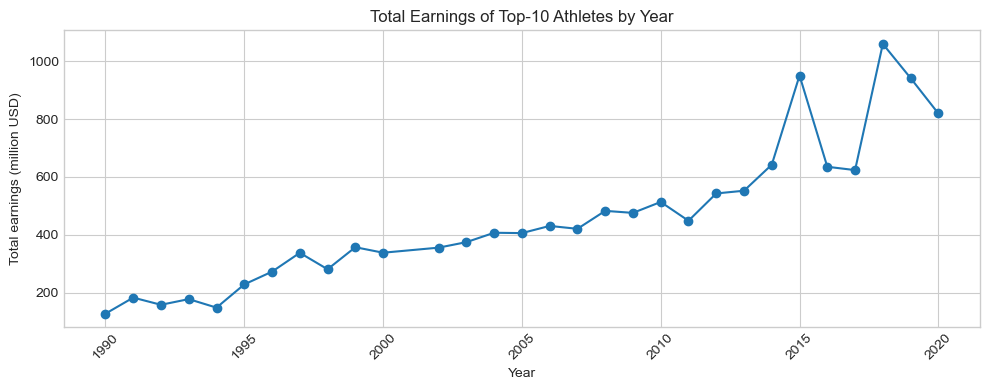

1990 total: 128.0 M  |  2020 total: 819.2 M
Approx. growth (1990→2020): 540 %


In [4]:
earnings_by_year = df.groupby('Year')['Earnings'].sum().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(earnings_by_year.index, earnings_by_year.values, marker='o', markersize=6, linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Total earnings (million USD)')
ax.set_title('Total Earnings of Top-10 Athletes by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('1990 total:', earnings_by_year.loc[1990], 'M  |  2020 total:', earnings_by_year.loc[2020], 'M')
print('Approx. growth (1990→2020):', round((earnings_by_year.loc[2020] / earnings_by_year.loc[1990] - 1) * 100), '%')

#### 3.2 Which sports dominate the ranking?

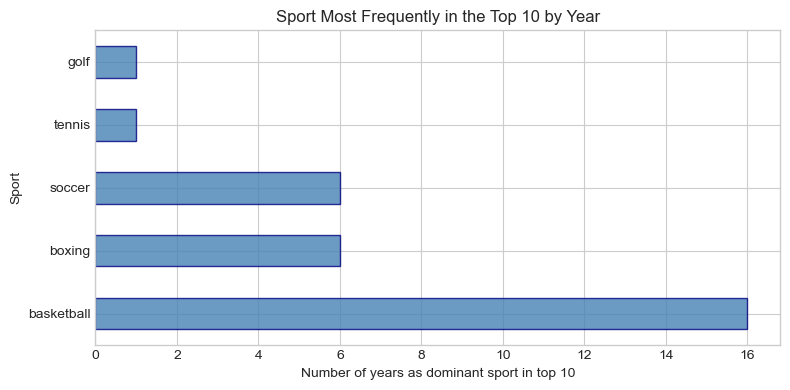

Dominant sport by period:
1990–1999: boxing
2000–2009: basketball
2010–2020: soccer


In [5]:
dominant_sport_by_year = df.groupby('Year')['Sport'].apply(lambda x: x.value_counts().index[0])
dominant_counts = dominant_sport_by_year.value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
dominant_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_xlabel('Number of years as dominant sport in top 10')
ax.set_title('Sport Most Frequently in the Top 10 by Year')
plt.tight_layout()
plt.show()

print('Dominant sport by period:')
print('1990–1999:', dominant_sport_by_year[dominant_sport_by_year.index <= 1999].value_counts().index[0])
print('2000–2009:', dominant_sport_by_year[(dominant_sport_by_year.index >= 2000) & (dominant_sport_by_year.index <= 2009)].value_counts().index[0])
print('2010–2020:', dominant_sport_by_year[dominant_sport_by_year.index >= 2010].value_counts().index[0])

#### 3.3 Concentration: share of earnings going to top 1, top 3, top 5

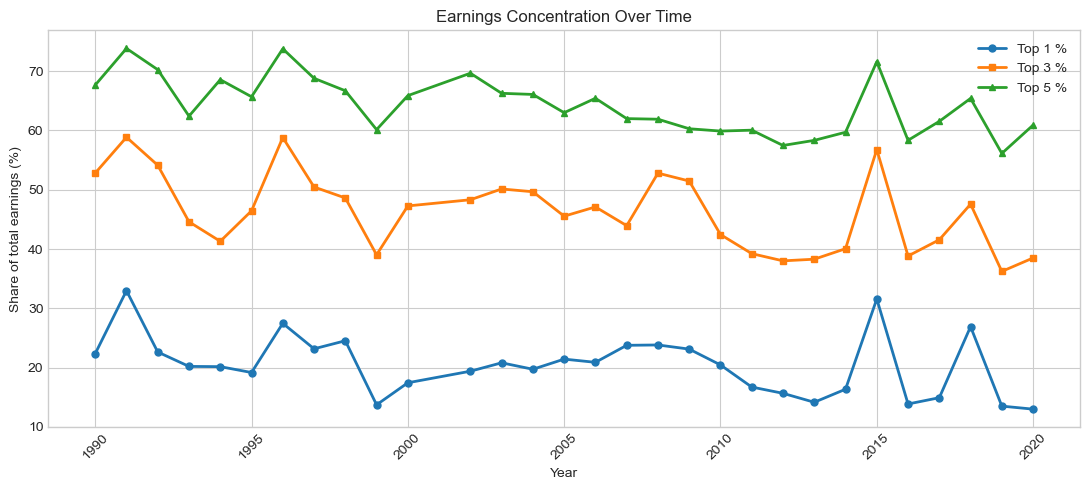

In [6]:
total = df.groupby('Year')['Earnings'].sum()
top1 = df[df['CurrentRank'] == 1].groupby('Year')['Earnings'].sum()
top3 = df[df['CurrentRank'] <= 3].groupby('Year')['Earnings'].sum()
top5 = df[df['CurrentRank'] <= 5].groupby('Year')['Earnings'].sum()

concentration = pd.DataFrame({
    'TotalEarnings': total,
    'Top1Pct': (top1 / total * 100).round(2),
    'Top3Pct': (top3 / total * 100).round(2),
    'Top5Pct': (top5 / total * 100).round(2)
}).sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(concentration.index, concentration['Top1Pct'], marker='o', label='Top 1 %', linewidth=2, markersize=5)
ax.plot(concentration.index, concentration['Top3Pct'], marker='s', label='Top 3 %', linewidth=2, markersize=5)
ax.plot(concentration.index, concentration['Top5Pct'], marker='^', label='Top 5 %', linewidth=2, markersize=5)
ax.set_xlabel('Year')
ax.set_ylabel('Share of total earnings (%)')
ax.set_title('Earnings Concentration Over Time')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
p1 = concentration[concentration.index <= 2005]
p2 = concentration[concentration.index >= 2006]

comparison = pd.DataFrame({
    '1990–2005': [p1['Top1Pct'].mean(), p1['Top3Pct'].mean(), p1['Top5Pct'].mean()],
    '2006–2020': [p2['Top1Pct'].mean(), p2['Top3Pct'].mean(), p2['Top5Pct'].mean()]
}, index=['Top 1', 'Top 3', 'Top 5'])
comparison['Change (pp)'] = comparison['2006–2020'] - comparison['1990–2005']
print(comparison.round(2))
t1_old, t1_new = comparison.loc['Top 1', '1990–2005'], comparison.loc['Top 1', '2006–2020']
print(f"\n→ Average Top 1 share: {t1_old:.1f}% (1990–2005) → {t1_new:.1f}% (2006–2020); concentration within the top 10 has slightly decreased.")

       1990–2005  2006–2020  Change (pp)
Top 1      21.67      19.24        -2.43
Top 3      49.06      43.52        -5.55
Top 5      67.25      61.27        -5.98

→ Average Top 1 share: 21.7% (1990–2005) → 19.2% (2006–2020); concentration within the top 10 has slightly decreased.


#### 3.4 Geographic mix (non-US share)

What share of top-10 appearances comes from outside the USA? Not a deep analysis, but a useful proxy for how global the list actually is.

In [8]:
us_count = (df['Nationality'] == 'USA').sum()
non_us_pct = (1 - us_count / len(df)) * 100
print(f"USA: {us_count} appearances ({100 - non_us_pct:.1f}%)  |  Rest of world: {len(df) - us_count} ({non_us_pct:.1f}%)")
df['Nationality'].value_counts().head(10)

USA: 206 appearances (68.4%)  |  Rest of world: 95 (31.6%)


Nationality
USA            206
UK              13
Germany         13
Switzerland     12
Portugal        10
Brazil           9
Argentina        9
Canada           6
Italy            4
France           3
Name: count, dtype: int64

In [9]:
def trend_slope(years, vals):
    slope, _, r, p, _ = stats.linregress(years, vals)
    return slope, r**2, p

for label, col in [('Top 1%', 'Top1Pct'), ('Top 3%', 'Top3Pct'), ('Top 5%', 'Top5Pct')]:
    sl, r2, p = trend_slope(concentration.index, concentration[col])
    direction = 'increasing' if sl > 0 else 'decreasing'
    print(f'{label}: slope = {sl:.4f} pp/year, R² = {r2:.3f}, p = {p:.3f} → {direction}')

Top 1%: slope = -0.2177 pp/year, R² = 0.153, p = 0.033 → decreasing
Top 3%: slope = -0.3741 pp/year, R² = 0.283, p = 0.002 → decreasing
Top 5%: slope = -0.3370 pp/year, R² = 0.411, p = 0.000 → decreasing


## 4. Key findings

- **Total earnings of the top 10 grew sharply** from 1990 to 2020 (roughly 5–6× in nominal terms), with a few years showing especially large jumps (e.g. 2015, 2018).
- **Sport dominance shifted over time**: boxing and tennis were strong in the early 1990s; basketball became the most represented sport in the top 10 for many years; in the last decade soccer has often come out on top.
- **Concentration did not increase in the second half of the period**: the share of total top-10 earnings going to the #1 athlete, top 3, and top 5 was actually **lower in 2006–2020 than in 1990–2005**. Within this slice of the list, earnings became slightly *less* concentrated, not more.
- **Linear trends** for Top1%, Top3%, and Top5% over the full period are **slightly negative** (a small decline in share over time), consistent with the two-period comparison.
- **Geographic skew**: the majority of appearances are from the USA; a handful of countries (UK, Germany, Switzerland, Portugal, Brazil) account for most of the rest.

## 5. What this means in practice

The total pool of earnings at the top of the list has grown substantially in nominal terms, but the share of that pool captured by the single top earner — or by the top 3 or top 5 — hasn’t increased. If anything, it’s slightly lower in the second half of the period. For anyone thinking about sponsorship or endorsement strategy, this suggests that spreading across a few top names may matter more than concentrating everything on one megastar.

The shift in which sports dominate the list is also worth noting. Soccer’s rise in the last decade reflects both global reach and the growth of the European club market. This has real implications for where media rights and partnership interest are heading.

A note on what the dataset *can’t* tell us: there’s no salary vs. endorsements split, and the analysis is limited to the top 10. Any claims about inequality in athlete earnings more broadly would require a wider dataset.

## 6. Next steps

- **Break out salary vs. endorsements** if that data is available from Forbes or third-party sources — the composition of earnings is at least as interesting as the totals.
- **Expand the list** beyond the top 10 (e.g. top 50 or 100) to see if concentration patterns look different with a larger pool.
- **Look at sport-level trends** more closely: how does each sport’s share of top-10 appearances correlate with TV deal cycles or global audience growth?
- **Update as new lists come out** — the concentration and trend analysis could easily be refreshed annually.

## 7. Metrics worth tracking over time

If this analysis is updated annually, the most useful numbers to track are: total top-10 earnings (to see overall growth), the Top1/Top3/Top5 concentration shares (to monitor whether earnings are bunching up), the dominant sport by year, and the non-US share of appearances. The linear slope of the concentration metrics over time is a single number that cleanly summarizes whether the list is getting more or less top-heavy.

*Data: Forbes richest athletes (1990–2020). Analysis in Python (pandas, matplotlib, scipy).*